In [3]:
%pip -q install open_clip_torch

In [4]:
import gc
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import matplotlib.pyplot as plt

from PIL import Image
from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode
from torchvision.models import resnet50, vit_b_16, ResNet50_Weights, ViT_B_16_Weights
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, f1_score
from google.colab import drive
from IPython.display import display
from tqdm.auto import tqdm

import open_clip

#! Reproducibility and runtime
SEED = 6304
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#! Existing project and new Part F folders
drive.mount("/content/drive")
TASK_ROOT = Path("/content/drive/MyDrive/pa1-beyond-iid/task1")
DATA_PATH = TASK_ROOT / "data/stl10_labeled.npz"
FEATURE_DIR = TASK_ROOT / "results/features"
HEAD_DIR = TASK_ROOT / "models/heads"
BASELINE_DIR = TASK_ROOT / "results/clean_baseline"
TRANSLATION_DIR = TASK_ROOT / "results/translation"
IMAGE_DIR = TRANSLATION_DIR / "images"
TRANSLATION_FEATURE_DIR = FEATURE_DIR / "translation"

for folder in (TRANSLATION_DIR, IMAGE_DIR, TRANSLATION_FEATURE_DIR):
    folder.mkdir(parents=True, exist_ok=True)

MODEL_NAMES = ["resnet50", "vit_b16", "clip_b32"]
MODEL_ORDER = MODEL_NAMES + ["clip_zero_shot"]
FEATURE_DIMS = {"resnet50": 2048, "vit_b16": 768, "clip_b32": 512}
DISPLACEMENTS = [0, 8, 16, 32]
DIRECTIONS = {"right": (1, 0), "left": (-1, 0), "down": (0, 1), "up": (0, -1)}
FEATURE_BATCH_SIZE = 16

#! The same official 500-image subset as Parts B–E
with np.load(DATA_PATH, allow_pickle=False) as data:
    test_images = data["test_images"]
    test_labels = data["test_labels"].astype(np.int64)
    test_indices = data["test_indices"].astype(np.int64)
    CLASS_NAMES = data["class_names"].tolist()

baseline_ids = np.load(BASELINE_DIR / "clean_image_ids.npy", allow_pickle=False)

if (len(test_images) != 500 or len(CLASS_NAMES) != 10
    or not np.array_equal(test_indices, baseline_ids)):
    raise ValueError("Part F test subset does not match Part C.")

required = ([HEAD_DIR / f"{name}_head.pt" for name in MODEL_NAMES]
            + [BASELINE_DIR / f"{name}_clean_predictions.npz" for name in MODEL_ORDER]
            + [FEATURE_DIR / "clip_zeroshot.pt"])

missing = [str(path) for path in required if not path.is_file()]

if missing:
    raise FileNotFoundError(f"Saved Part B/C artifacts missing: {missing}")

#! Load paired clean predictions once, before any shifted evaluation
clean_data = {}

for model_name in MODEL_ORDER:
    with np.load(BASELINE_DIR / f"{model_name}_clean_predictions.npz", allow_pickle=False) as saved:
        if (not np.array_equal(saved["image_ids"], test_indices)
            or not np.array_equal(saved["y_true"], test_labels)):
            raise ValueError(f"Misaligned clean predictions: {model_name}")

        clean_data[model_name] = {
            "y_pred": saved["y_pred"].astype(np.int64).copy(),
            "confidence": saved["max_confidence"].copy()
        }

#! Declare the entire transformation protocol before observing results
plan = {
    "experiment": "Task 1 Part F - Translation Sensitivity",
    "seed": SEED,
    "dataset": "STL-10, same 500 clean test images from Part C",
    "displacements_pixels": DISPLACEMENTS,
    "directions": {name: list(vector) for name, vector in DIRECTIONS.items()},
    "common_image": "RGB, bicubic resize to 224x224 before shift and model normalization",
    "translation": "reflect-pad by displacement, shifted 224x224 crop; positive dx moves object right, positive dy moves it down",
    "direction_aggregation": "arithmetic mean over the 4 directions at each positive displacement; clean at 0 is counted once",
    "metrics": ["accuracy", "prediction_consistency", "accuracy_change_pp", "macro_f1", "mean_max_confidence"],
    "hypothesis_for_experiment_planning_only": "Test whether larger displacements decrease accuracy and paired prediction consistency; no predetermined model ranking.",
    "note": "Transformed image tensor is deterministic from canonical_224.pt + displacement/direction; all models use the same tensor."
}

config_path = TRANSLATION_DIR / "experiment_config.json"

if config_path.is_file():
    with open(config_path) as f:
        if json.load(f) != plan:
            raise ValueError("Saved translation plan differs; inspect before overwriting prior results.")
else:
    with open(config_path, "w") as f:
        json.dump(plan, f, indent=2)

print("Device:", DEVICE)
print("Evaluation images:", len(test_indices))
print("Shift settings:", DISPLACEMENTS, list(DIRECTIONS))
print("Output:", TRANSLATION_DIR)

Mounted at /content/drive
Device: cuda
Evaluation images: 500
Shift settings: [0, 8, 16, 32] ['right', 'left', 'down', 'up']
Output: /content/drive/MyDrive/pa1-beyond-iid/task1/results/translation


In [5]:
#! Save the 224x224 pixels used by every model
canonical_path = IMAGE_DIR / "canonical_224.pt"

if not canonical_path.is_file():
    images_224 = torch.empty((500, 3, 224, 224), dtype=torch.uint8)

    for i in tqdm(range(500), desc="Canonical RGB resize"):
        image = Image.fromarray(np.transpose(test_images[i], (1, 2, 0))).convert("RGB")
        image = TF.resize(image, [224, 224], interpolation=InterpolationMode.BICUBIC)
        images_224[i] = torch.from_numpy(np.asarray(image, dtype=np.uint8).copy()).permute(2, 0, 1)
    torch.save({
        "images": images_224,
        "indices": torch.from_numpy(test_indices.copy()),
        "labels": torch.from_numpy(test_labels.copy()),
        "seed": SEED,
        "size": 224
    }, canonical_path)

saved = torch.load(canonical_path, map_location="cpu", weights_only=True)

if (saved["images"].shape != (500, 3, 224, 224)
    or saved["images"].dtype != torch.uint8
    or not np.array_equal(saved["indices"].numpy(), test_indices)
    or not np.array_equal(saved["labels"].numpy(), test_labels)
    or saved["seed"] != SEED):
    raise ValueError("Existing canonical cache has incompatible image IDs, pixels, or seed.")

canonical_images = saved["images"]

#! One clean setting and 12 positive displacement-direction settings
conditions = [{"condition": "clean", "displacement": 0, "direction": "none", "dx": 0, "dy": 0}]

for displacement in DISPLACEMENTS[1:]:
    for direction, (x_sign, y_sign) in DIRECTIONS.items():
        conditions.append({
            "condition": f"shift{displacement}_{direction}",
            "displacement": displacement,
            "direction": direction,
            "dx": x_sign * displacement,
            "dy": y_sign * displacement
        })

manifest_path = TRANSLATION_DIR / "transformation_manifest.csv"
manifest = pd.DataFrame(conditions)
if manifest_path.is_file():
    previous = pd.read_csv(manifest_path)
    if not previous.equals(manifest):
        raise ValueError("Existing transformation manifest differs; do not silently overwrite.")
else:
    manifest.to_csv(manifest_path, index=False)

print("Canonical cache:", canonical_path)
display(manifest)

Canonical RGB resize:   0%|          | 0/500 [00:00<?, ?it/s]

Canonical cache: /content/drive/MyDrive/pa1-beyond-iid/task1/results/translation/images/canonical_224.pt


,condition,displacement,direction,dx,dy
0,clean,0,none,0,0
1,shift8_right,8,right,8,0
2,shift8_left,8,left,-8,0
3,shift8_down,8,down,0,8
4,shift8_up,8,up,0,-8
5,shift16_right,16,right,16,0
6,shift16_left,16,left,-16,0
7,shift16_down,16,down,0,16
8,shift16_up,16,up,0,-16
9,shift32_right,32,right,32,0


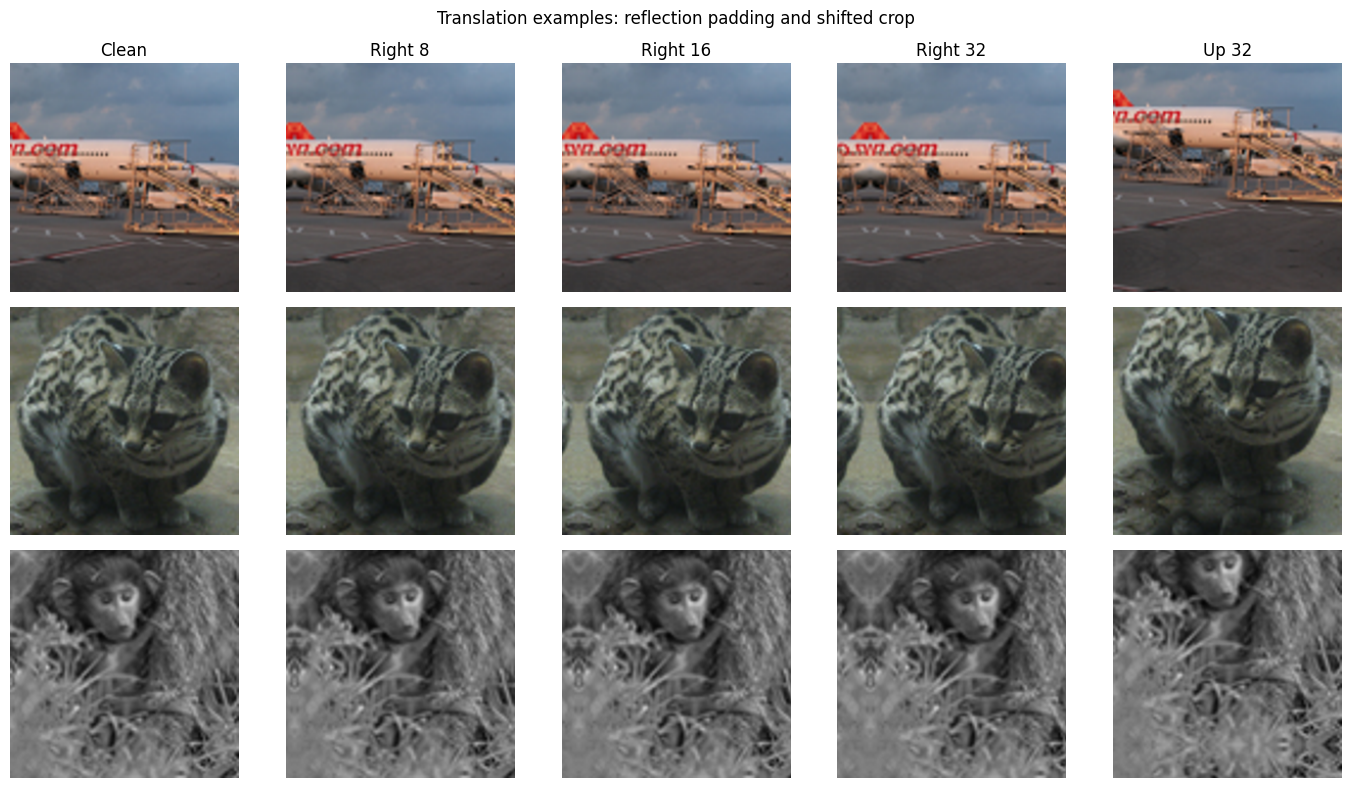

Saved translation_examples.png and example_image_ids.csv


In [6]:
#! Deterministic integer-pixel shift on a batch of NCHW images
def translate_reflect(images, dx, dy):
    padding = max(abs(dx), abs(dy))

    if padding == 0:
        return images

    height, width = images.shape[-2:]
    padded = F.pad(images, (padding, padding, padding, padding), mode="reflect")
    start_x = padding - dx
    start_y = padding - dy
    return padded[:, :, start_y:start_y + height, start_x:start_x + width]

#! Pixel-level sanity check, independent of the classifiers
sample = torch.zeros(1, 1, 9, 9)
sample[0, 0, 4, 4] = 1

for dx, dy in ((3, 0), (-3, 0), (0, 3), (0, -3)):
    moved = translate_reflect(sample, dx, dy)
    y, x = torch.nonzero(moved[0, 0], as_tuple=True)

    if (int(x[0]), int(y[0])) != (4 + dx, 4 + dy):
        raise RuntimeError("Shift direction does not match its label.")

#! Show one fixed source at four shift distances in two directions
example_positions = [int(np.flatnonzero(test_labels == c)[0]) for c in (0, 3, 7)]
fig, axes = plt.subplots(len(example_positions), 5, figsize=(14, 8))
examples = []

for row, position in enumerate(example_positions):
    image = canonical_images[position:position + 1].float().div(255.0)
    variants = [("Clean", 0, 0), ("Right 8", 8, 0), ("Right 16", 16, 0),
                ("Right 32", 32, 0), ("Up 32", 0, -32)]

    for col, (title, dx, dy) in enumerate(variants):
        output = translate_reflect(image, dx, dy)[0].permute(1, 2, 0).numpy()
        axes[row, col].imshow(output)
        axes[row, col].set_title(title if row == 0 else "")
        axes[row, col].axis("off")

    examples.append({"image_id": int(test_indices[position]),
                     "class_name": CLASS_NAMES[int(test_labels[position])],
                     "subset_position": position})
    axes[row, 0].set_ylabel(CLASS_NAMES[int(test_labels[position])])

fig.suptitle("Translation examples: reflection padding and shifted crop")
fig.tight_layout()
fig.savefig(TRANSLATION_DIR / "translation_examples.png", dpi=250, bbox_inches="tight")

plt.show()

pd.DataFrame(examples).to_csv(TRANSLATION_DIR / "example_image_ids.csv", index=False)

print("Saved translation_examples.png and example_image_ids.csv")

In [7]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)
CLIP_MEAN = (0.48145466, 0.4578275, 0.40821073)
CLIP_STD = (0.26862954, 0.26130258, 0.27577711)

#! Part B backbone definitions, with no classifier fine-tuning
def load_backbone(model_name):

    if model_name == "resnet50":
        backbone = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        backbone.fc = nn.Identity()
    elif model_name == "vit_b16":
        backbone = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
        backbone.heads = nn.Identity()
    elif model_name == "clip_b32":
        backbone, _, _ = open_clip.create_model_and_transforms("ViT-B-32", pretrained="openai")
    else:
        raise ValueError(f"Unknown backbone: {model_name}")

    for parameter in backbone.parameters():
        parameter.requires_grad = False

    return backbone.to(DEVICE).eval()


@torch.inference_mode()

def extract_shift_features(backbone, displacement, dx, dy, model_name):
    loader = DataLoader(
        TensorDataset(canonical_images, torch.from_numpy(test_labels.copy())),
        batch_size=FEATURE_BATCH_SIZE, shuffle=False, num_workers=0,
        pin_memory=(DEVICE.type == "cuda")
    )

    mean_values, std_values = ((CLIP_MEAN, CLIP_STD) if model_name == "clip_b32"
                               else (IMAGENET_MEAN, IMAGENET_STD))

    mean = torch.tensor(mean_values, dtype=torch.float32, device=DEVICE).view(1, 3, 1, 1)
    std = torch.tensor(std_values, dtype=torch.float32, device=DEVICE).view(1, 3, 1, 1)
    outputs = []

    for images, _ in tqdm(loader, desc=f"{model_name}: {displacement}px ({dx},{dy})"):
        images = images.to(DEVICE, non_blocking=True).float().div(255.0)
        images = translate_reflect(images, dx, dy)
        images = (images - mean) / std

        if model_name == "clip_b32":
            features = F.normalize(backbone.encode_image(images).float(), p=2, dim=-1)
        else:
            features = backbone(images).float()
        outputs.append(features.cpu())

    return torch.cat(outputs, dim=0).float()


#! Skip and verify existing feature caches; compute only missing conditions
shift_rows = manifest[manifest.displacement > 0].to_dict("records")

for model_name in MODEL_NAMES:
    needed = []

    for row in shift_rows:
        path = TRANSLATION_FEATURE_DIR / f"{model_name}_{row['condition']}.pt"

        if path.is_file():
            entry = torch.load(path, map_location="cpu", weights_only=True)

            if (entry["features"].shape != (500, FEATURE_DIMS[model_name])
                or not np.array_equal(entry["indices"].numpy(), test_indices)
                or not np.array_equal(entry["labels"].numpy(), test_labels)
                or entry["dx"] != row["dx"] or entry["dy"] != row["dy"]
                or entry["seed"] != SEED):
                raise ValueError(f"Incompatible prior feature cache: {path}")
            print("Reusing:", path.name)
        else:
            needed.append(row)

    if not needed:
        continue

    backbone = load_backbone(model_name)

    for row in needed:
        features = extract_shift_features(
            backbone, row["displacement"], row["dx"], row["dy"], model_name
        )

        if features.shape != (500, FEATURE_DIMS[model_name]) or not torch.isfinite(features).all():
            raise ValueError(f"Invalid extracted features: {model_name}, {row['condition']}")
        path = TRANSLATION_FEATURE_DIR / f"{model_name}_{row['condition']}.pt"
        torch.save({
            "features": features,
            "labels": torch.from_numpy(test_labels.copy()),
            "indices": torch.from_numpy(test_indices.copy()),
            "seed": SEED, "condition": row["condition"],
            "displacement": row["displacement"], "direction": row["direction"],
            "dx": row["dx"], "dy": row["dy"]
        }, path)
        print("Saved:", path.name)
        del features

    del backbone
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("All 36 translated-feature caches are saved.")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 113MB/s]


resnet50: 8px (8,0):   0%|          | 0/32 [00:00<?, ?it/s]

Saved: resnet50_shift8_right.pt


resnet50: 8px (-8,0):   0%|          | 0/32 [00:00<?, ?it/s]

...

Saved: clip_b32_shift32_left.pt


clip_b32: 32px (0,32):   0%|          | 0/32 [00:00<?, ?it/s]

Saved: clip_b32_shift32_down.pt


clip_b32: 32px (0,-32):   0%|          | 0/32 [00:00<?, ?it/s]

Saved: clip_b32_shift32_up.pt
All 36 translated-feature caches are saved.


In [8]:
#! Fixed zero-shot classifier from Part B
zero_shot = torch.load(FEATURE_DIR / "clip_zeroshot.pt", map_location="cpu", weights_only=True)
text_features = zero_shot["text_features"].float()
logit_scale = float(zero_shot["logit_scale"])  #! Already exp(logit_scale)
expected_prompts = [f"a photo of a {name}." for name in CLASS_NAMES]

if zero_shot["class_names"] != CLASS_NAMES or zero_shot["prompts"] != expected_prompts:
    raise ValueError("CLIP prompt or class order differs from Part B.")

#! One evaluation routine for linear and zero-shot logits
summary_rows = []
prediction_rows = []

def evaluate_condition(model_name, row, logits):
    condition = row["condition"]
    clean_pred = clean_data[model_name]["y_pred"]

    with torch.inference_mode():
        probabilities = torch.softmax(logits.float(), dim=1)
        confidence, predicted = probabilities.max(dim=1)

    y_pred = predicted.cpu().numpy().astype(np.int64)
    conf = confidence.cpu().numpy()
    acc = float(accuracy_score(test_labels, y_pred))
    clean_acc = float(accuracy_score(test_labels, clean_pred))
    consistency = float(np.mean(y_pred == clean_pred))

    np.savez_compressed(
        TRANSLATION_DIR / f"{model_name}_{condition}_predictions.npz",
        image_ids=test_indices, y_true=test_labels, y_pred=y_pred,
        clean_y_pred=clean_pred, logits=logits.cpu().numpy(),
        probabilities=probabilities.cpu().numpy(), max_confidence=conf,
        prediction_changed=(y_pred != clean_pred), correct=(y_pred == test_labels),
        displacement=np.int64(row["displacement"]), dx=np.int64(row["dx"]), dy=np.int64(row["dy"])
    )

    summary_rows.append({
        "model": model_name, "condition": condition,
        "displacement": int(row["displacement"]), "direction": row["direction"],
        "dx": int(row["dx"]), "dy": int(row["dy"]), "n_images": 500,
        "clean_accuracy": clean_acc, "accuracy": acc,
        "accuracy_change_pp": 100.0 * (acc - clean_acc),
        "prediction_consistency": consistency,
        "macro_f1": float(f1_score(test_labels, y_pred, labels=list(range(10)),
                                   average="macro", zero_division=0)),
        "mean_max_confidence": float(conf.mean()),
        "n_changed": int((y_pred != clean_pred).sum()), "seed": SEED
    })

    prediction_rows.extend({
        "image_id": int(test_indices[i]), "model": model_name,
        "condition": condition, "displacement": int(row["displacement"]),
        "direction": row["direction"], "true_label": int(test_labels[i]),
        "clean_prediction": int(clean_pred[i]), "shifted_prediction": int(y_pred[i]),
        "prediction_changed": bool(y_pred[i] != clean_pred[i]),
        "max_confidence": float(conf[i])
    } for i in range(500))

    print(f"{model_name} / {condition}: acc={acc:.4f}, consistency={consistency:.4f}")


#! Saved linear heads, no training or backbone inference here
for model_name in MODEL_NAMES:

    checkpoint = torch.load(HEAD_DIR / f"{model_name}_head.pt", map_location="cpu", weights_only=True)

    if checkpoint["model_name"] != model_name or checkpoint["seed"] != SEED:
        raise ValueError(f"Incorrect classifier checkpoint: {model_name}")
    head = nn.Linear(checkpoint["in_features"], checkpoint["num_classes"])
    head.load_state_dict(checkpoint["head_state_dict"])
    head.eval()

    for row in shift_rows:
        saved = torch.load(TRANSLATION_FEATURE_DIR / f"{model_name}_{row['condition']}.pt",
                           map_location="cpu", weights_only=True)

        if not np.array_equal(saved["indices"].numpy(), test_indices):
            raise ValueError(f"Feature-image mismatch: {model_name}/{row['condition']}")

        with torch.inference_mode():
            logits = head(saved["features"].float())
        evaluate_condition(model_name, row, logits)

        #! Reuse precisely the same translated CLIP embeddings for zero-shot
        if model_name == "clip_b32":
            with torch.inference_mode():
                zero_logits = logit_scale * (saved["features"].float() @ text_features.T)
            evaluate_condition("clip_zero_shot", row, zero_logits)
    del head

#! Full direction-level results and per-image correspondence
per_direction_df = pd.DataFrame(summary_rows)
per_direction_df.to_csv(TRANSLATION_DIR / "per_direction.csv", index=False)

pd.DataFrame(prediction_rows).to_csv(TRANSLATION_DIR / "predictions.csv", index=False)

print("Saved 48 per-condition prediction archives and per_direction.csv")

display(per_direction_df.round(4).head(12))

resnet50 / shift8_right: acc=0.9720, consistency=0.9960
resnet50 / shift8_left: acc=0.9760, consistency=0.9960
resnet50 / shift8_down: acc=0.9740, consistency=0.9920
resnet50 / shift8_up: acc=0.9740, consistency=0.9960
resnet50 / shift16_right: acc=0.9720, consistency=0.9940
resnet50 / shift16_left: acc=0.9720, consistency=0.9860
resnet50 / shift16_down: acc=0.9720, consistency=0.9940
resnet50 / shift16_up: acc=0.9680, consistency=0.9920
resnet50 / shift32_right: acc=0.9620, consistency=0.9860
resnet50 / shift32_left: acc=0.9680, consistency=0.9840
resnet50 / shift32_down: acc=0.9640, consistency=0.9860
resnet50 / shift32_up: acc=0.9700, consistency=0.9920
vit_b16 / shift8_right: acc=0.9760, consistency=0.9860
vit_b16 / shift8_left: acc=0.9760, consistency=0.9820
vit_b16 / shift8_down: acc=0.9780, consistency=0.9860
vit_b16 / shift8_up: acc=0.9760, consistency=0.9840
vit_b16 / shift16_right: acc=0.9680, consistency=0.9880
vit_b16 / shift16_left: acc=0.9720, consistency=0.9860
vit_b16 /

,model,condition,displacement,direction,dx,dy,n_images,clean_accuracy,accuracy,accuracy_change_pp,prediction_consistency,macro_f1,mean_max_confidence,n_changed,seed
0,resnet50,shift8_right,8,right,8,0,500,0.976,0.972,-0.4,0.996,0.9721,0.9338,2,6304
1,resnet50,shift8_left,8,left,-8,0,500,0.976,0.976,0.0,0.996,0.9760,0.9350,2,6304
2,resnet50,shift8_down,8,down,0,8,500,0.976,0.974,-0.2,0.992,0.9740,0.9316,4,6304
3,resnet50,shift8_up,8,up,0,-8,500,0.976,0.974,-0.2,0.996,0.9741,0.9347,2,6304
4,resnet50,shift16_right,16,right,16,0,500,0.976,0.972,-0.4,0.994,0.9721,0.9270,3,6304
5,resnet50,shift16_left,16,left,-16,0,500,0.976,0.972,-0.4,0.986,0.9720,0.9333,7,6304
6,resnet50,shift16_down,16,down,0,16,500,0.976,0.972,-0.4,0.994,0.9721,0.9262,3,6304
7,resnet50,shift16_up,16,up,0,-16,500,0.976,0.968,-0.8,0.992,0.9680,0.9363,4,6304
8,resnet50,shift32_right,32,right,32,0,500,0.976,0.962,-1.4,0.986,0.9622,0.9245,7,6304
9,resnet50,shift32_left,32,left,-32,0,500,0.976,0.968,-0.8,0.984,0.9681,0.9261,8,6304


In [9]:
#! Average directions; no fourth duplicated clean inference

aggregate_rows = []

for model_name in MODEL_ORDER:
    clean_pred = clean_data[model_name]["y_pred"]
    clean_acc = float(accuracy_score(test_labels, clean_pred))
    clean_f1 = float(f1_score(test_labels, clean_pred, labels=list(range(10)),
                              average="macro", zero_division=0))

    aggregate_rows.append({
        "model": model_name, "displacement": 0, "n_directions": 1,
        "accuracy": clean_acc, "accuracy_std": 0.0,
        "prediction_consistency": 1.0, "consistency_std": 0.0,
        "accuracy_change_pp": 0.0, "macro_f1_mean": clean_f1,
        "mean_max_confidence_mean": float(clean_data[model_name]["confidence"].mean()),
        "seed": SEED
    })

    for displacement in DISPLACEMENTS[1:]:
        subset = per_direction_df.loc[
            (per_direction_df.model == model_name)
            & (per_direction_df.displacement == displacement)
        ]

        if set(subset.direction) != set(DIRECTIONS) or len(subset) != 4:
            raise ValueError(f"Incomplete directions for {model_name}, {displacement}px")

        accuracy_mean = float(subset.accuracy.mean())
        aggregate_rows.append({
            "model": model_name, "displacement": displacement,
            "n_directions": 4, "accuracy": accuracy_mean,
            "accuracy_std": float(subset.accuracy.std(ddof=0)),
            "prediction_consistency": float(subset.prediction_consistency.mean()),
            "consistency_std": float(subset.prediction_consistency.std(ddof=0)),
            "accuracy_change_pp": 100.0 * (accuracy_mean - clean_acc),
            "macro_f1_mean": float(subset.macro_f1.mean()),
            "mean_max_confidence_mean": float(subset.mean_max_confidence.mean()),
            "seed": SEED
        })

summary_df = pd.DataFrame(aggregate_rows).sort_values(["model", "displacement"])
summary_df.to_csv(TRANSLATION_DIR / "summary.csv", index=False)

with open(TRANSLATION_DIR / "summary.json", "w") as f:
    json.dump({"seed": SEED, "method": "four-direction mean, 0 from clean baseline",
               "results": aggregate_rows}, f, indent=2)

print("Translation sensitivity (means; fractions 0–1, accuracy change in pp)")
display(summary_df.round(4))

Translation sensitivity (means; fractions 0–1, accuracy change in pp)


,model,displacement,n_directions,accuracy,accuracy_std,prediction_consistency,consistency_std,accuracy_change_pp,macro_f1_mean,mean_max_confidence_mean,seed
8,clip_b32,0,1,0.9800,0.0000,1.0000,0.0000,0.00,0.9800,0.2415,6304
9,clip_b32,8,4,0.9810,0.0022,0.9865,0.0048,0.10,0.9810,0.2400,6304
10,clip_b32,16,4,0.9770,0.0033,0.9825,0.0022,-0.30,0.9769,0.2357,6304
11,clip_b32,32,4,0.9735,0.0036,0.9795,0.0055,-0.65,0.9734,0.2310,6304
12,clip_zero_shot,0,1,0.9680,0.0000,1.0000,0.0000,0.00,0.9675,0.9427,6304
13,clip_zero_shot,8,4,0.9690,0.0022,0.9810,0.0022,0.10,0.9685,0.9417,6304
14,clip_zero_shot,16,4,0.9725,0.0026,0.9795,0.0030,0.45,0.9722,0.9385,6304
15,clip_zero_shot,32,4,0.9560,0.0045,0.9730,0.0046,-1.20,0.9555,0.9275,6304
0,resnet50,0,1,0.9760,0.0000,1.0000,0.0000,0.00,0.9761,0.9349,6304
1,resnet50,8,4,0.9740,0.0014,0.9950,0.0017,-0.20,0.9741,0.9338,6304


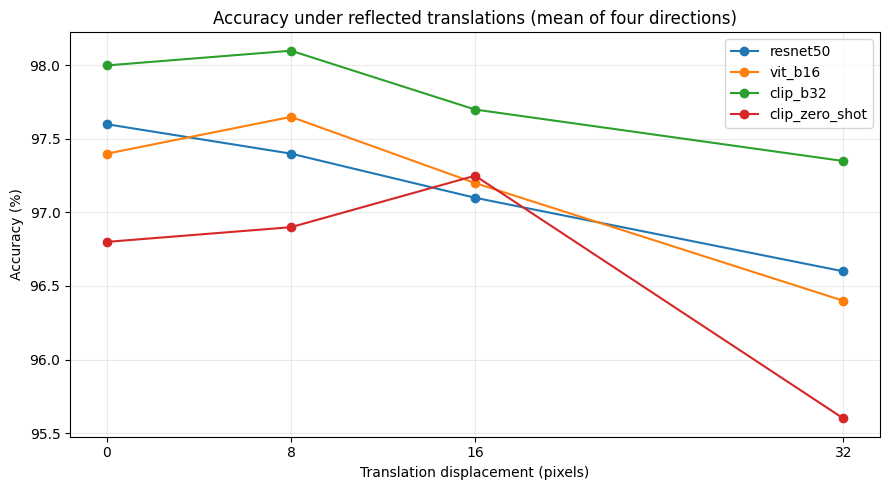

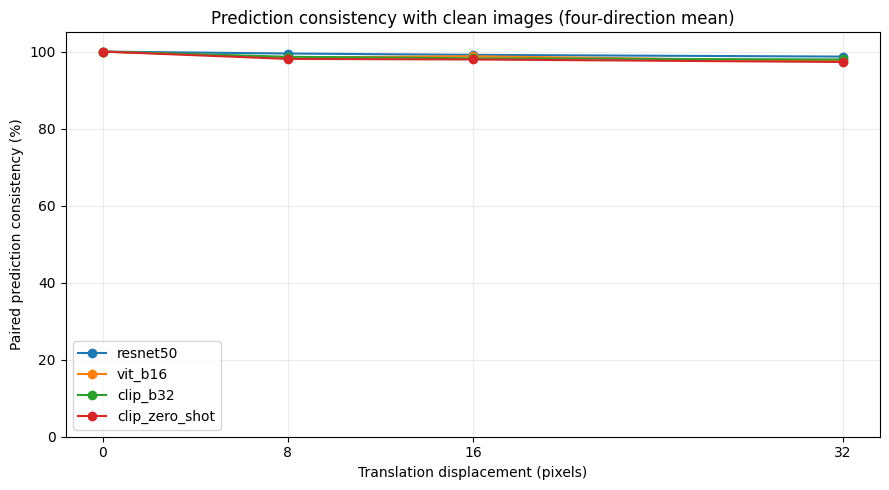

Saved both 300-dpi displacement curves.


In [10]:
#! Accuracy versus displacement

fig, ax = plt.subplots(figsize=(9, 5))

for model_name in MODEL_ORDER:
    subset = summary_df.loc[summary_df.model == model_name].sort_values("displacement")
    ax.plot(subset.displacement, 100 * subset.accuracy, marker="o", label=model_name)

ax.set_xticks(DISPLACEMENTS)
ax.set_xlabel("Translation displacement (pixels)")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Accuracy under reflected translations (mean of four directions)")
ax.grid(alpha=0.25)
ax.legend()

fig.tight_layout()
fig.savefig(TRANSLATION_DIR / "translation_accuracy_curve.png", dpi=300, bbox_inches="tight")

plt.show()

#! Paired prediction consistency versus displacement
fig, ax = plt.subplots(figsize=(9, 5))

for model_name in MODEL_ORDER:
    subset = summary_df.loc[summary_df.model == model_name].sort_values("displacement")
    ax.plot(subset.displacement, 100 * subset.prediction_consistency, marker="o", label=model_name)

ax.set_xticks(DISPLACEMENTS)
ax.set_ylim(0, 105)
ax.set_xlabel("Translation displacement (pixels)")
ax.set_ylabel("Paired prediction consistency (%)")
ax.set_title("Prediction consistency with clean images (four-direction mean)")
ax.grid(alpha=0.25)
ax.legend()

fig.tight_layout()
fig.savefig(TRANSLATION_DIR / "translation_consistency_curve.png", dpi=300, bbox_inches="tight")

plt.show()

print("Saved both 300-dpi displacement curves.")

In [11]:
#! Check artifacts needed for reproducible figures and downstream representation analysis

required_files = [
    TRANSLATION_DIR / "experiment_config.json",
    TRANSLATION_DIR / "transformation_manifest.csv",
    TRANSLATION_DIR / "example_image_ids.csv",
    TRANSLATION_DIR / "translation_examples.png",
    TRANSLATION_DIR / "per_direction.csv",
    TRANSLATION_DIR / "predictions.csv",
    TRANSLATION_DIR / "summary.csv",
    TRANSLATION_DIR / "summary.json",
    TRANSLATION_DIR / "translation_accuracy_curve.png",
    TRANSLATION_DIR / "translation_consistency_curve.png",
    IMAGE_DIR / "canonical_224.pt"
]

required_files.extend(TRANSLATION_FEATURE_DIR / f"{name}_{row['condition']}.pt"
                      for name in MODEL_NAMES for row in shift_rows)
required_files.extend(TRANSLATION_DIR / f"{name}_{row['condition']}_predictions.npz"
                      for name in MODEL_ORDER for row in shift_rows)

missing = [str(path) for path in required_files if not path.is_file()]
if missing:
    raise FileNotFoundError(f"Missing Part F outputs: {missing}")

saved_direction = pd.read_csv(TRANSLATION_DIR / "per_direction.csv")
saved_summary = pd.read_csv(TRANSLATION_DIR / "summary.csv")

if (len(saved_direction) != 48 or len(saved_summary) != 16
    or set(saved_summary.displacement) != set(DISPLACEMENTS)
    or not (saved_direction.n_images == 500).all()):
    raise ValueError("Saved translation table is incomplete.")

#! Verify a single stored condition for every model against original image IDs
first_condition = shift_rows[0]["condition"]

for model_name in MODEL_ORDER:
    with np.load(TRANSLATION_DIR / f"{model_name}_{first_condition}_predictions.npz",
                 allow_pickle=False) as saved:

        if (not np.array_equal(saved["image_ids"], test_indices)
            or len(saved["y_pred"]) != 500):
            raise ValueError(f"Prediction archive is misaligned: {model_name}")

    print(f"{model_name}: 12 translated conditions saved")

print("\nPART F COMPLETE — files verified:", len(required_files))
print("Results:", TRANSLATION_DIR)
display(saved_summary.round(4))

resnet50: 12 translated conditions saved
vit_b16: 12 translated conditions saved
clip_b32: 12 translated conditions saved
clip_zero_shot: 12 translated conditions saved

PART F COMPLETE — files verified: 95
Results: /content/drive/MyDrive/pa1-beyond-iid/task1/results/translation


,model,displacement,n_directions,accuracy,accuracy_std,prediction_consistency,consistency_std,accuracy_change_pp,macro_f1_mean,mean_max_confidence_mean,seed
0,clip_b32,0,1,0.9800,0.0000,1.0000,0.0000,0.00,0.9800,0.2415,6304
1,clip_b32,8,4,0.9810,0.0022,0.9865,0.0048,0.10,0.9810,0.2400,6304
2,clip_b32,16,4,0.9770,0.0033,0.9825,0.0022,-0.30,0.9769,0.2357,6304
3,clip_b32,32,4,0.9735,0.0036,0.9795,0.0055,-0.65,0.9734,0.2310,6304
4,clip_zero_shot,0,1,0.9680,0.0000,1.0000,0.0000,0.00,0.9675,0.9427,6304
5,clip_zero_shot,8,4,0.9690,0.0022,0.9810,0.0022,0.10,0.9685,0.9417,6304
6,clip_zero_shot,16,4,0.9725,0.0026,0.9795,0.0030,0.45,0.9722,0.9385,6304
7,clip_zero_shot,32,4,0.9560,0.0045,0.9730,0.0046,-1.20,0.9555,0.9275,6304
8,resnet50,0,1,0.9760,0.0000,1.0000,0.0000,0.00,0.9761,0.9349,6304
9,resnet50,8,4,0.9740,0.0014,0.9950,0.0017,-0.20,0.9741,0.9338,6304
